In [1]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from scqat.protocols.qubit_decoherence import QubitDecoherenceAnalyzer
from scqat.math_tools.fit_qubit_decoherence import rho11_model
from scqat.math_tools.fit_multi_damped_oscillation import multi_damped_osc_eval
from scqat.workflows.ep_pipeline import analyze_file

In [2]:
# Define the path to the h5 file and run the full EP tomography → decoherence pipeline.
# h5_file_path = r'/Users/jacky/Library/CloudStorage/SynologyDrive-LCH_AS/data/EP/Parametric_drive/QtoR/20260210_tomo/x180/#1512_LCH_qubit_parametric_drive_time_tomo_4_232122/ds_raw.h5'
h5_file_path = r'/Users/jacky/Library/CloudStorage/SynologyDrive-LCH_AS/data/EP/Parametric_drive/QtoR/20260210_tomo/x180/#1509_LCH_qubit_parametric_drive_time_tomo_1_225238/ds_raw.h5'

if not os.path.exists(h5_file_path):
    raise FileNotFoundError(f"File not found: {h5_file_path}")
print(f"Found h5 file: {h5_file_path}")

# analyze_file does: load → split per qubit → build rho dataset → Hankel → MDO → decoherence fit.
results = analyze_file(h5_file_path)

qubit_data            = [r["sq_data"]        for r in results]
rho_datasets          = [r["rho_ds"]         for r in results]
hankel_diagnostics    = [r["hankel"]         for r in results]
mdo_fit_results       = [r["mdo"]            for r in results]
decoh_fit_results     = [r["decoh"]          for r in results]
decoh_initial_guesses = [r["decoh_guesses"]  for r in results]

print(f"\nAnalyzed {len(results)} qubit dataset(s).")
for r in results:
    print(f"  - {r['qubit_name']}: rho dims = {dict(r['rho_ds'].sizes)}")

Found h5 file: /Users/jacky/Library/CloudStorage/SynologyDrive-LCH_AS/data/EP/Parametric_drive/QtoR/20260210_tomo/x180/#1509_LCH_qubit_parametric_drive_time_tomo_1_225238/ds_raw.h5
(array([0, 1]),)
2
(array([0, 1]),)
2
(array([0, 1]),)
2
(array([0, 1]),)
2
(array([0, 1]),)
2
(array([0, 1]),)
2
(array([0, 1]),)
2
(array([0, 1]),)
2
(array([0, 1]),)
2
(array([0, 1]),)
2
(array([0, 1]),)
2
[q1] freqs=11  hankel_seeded=11  mdo_ok=11  decoh_ok=11

Analyzed 1 qubit dataset(s).
  - q1: rho dims = {'driving_time': 150, 'driving_frequency': 11}


Creating heatmaps...
Selected basis index 2 from coordinate

Processing qubit 0: q1
Available data variables: ['state']
Available coordinates: ['driving_time', 'driving_frequency', 'basis']


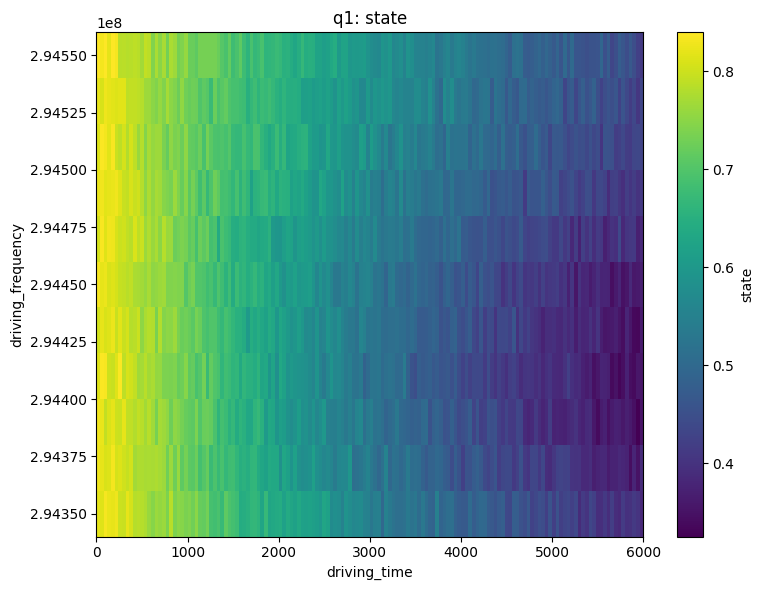


Heatmap creation complete!


In [3]:
print("Creating heatmaps...")

for i, sq_data in enumerate(qubit_data):
    # Select index 2 from basis coordinate if it exists
    if 'basis' in sq_data.coords:
        sq_data = sq_data.isel(basis=2)
        print(f"Selected basis index 2 from coordinate")

    try:
        qubit_name = sq_data["qubit"].values.item() if "qubit" in sq_data else f"Dataset_{i}"
        print(f"\nProcessing qubit {i}: {qubit_name}")
    except Exception:
        qubit_name = f"Dataset_{i}"
        print(f"\nProcessing dataset {i}")

    # Get available data variables and coordinates
    data_vars = list(sq_data.data_vars.keys())
    coords = [c for c in sq_data.coords.keys() if c != 'qubit']
    print(f"Available data variables: {data_vars}")
    print(f"Available coordinates: {coords}")

    # User-specified plotting parameters
    x_dim = "driving_time"
    y_dim = "driving_frequency"
    data_var = "state"

    # Extract the 2D data array and ensure axis ordering (y, x)
    da = sq_data[data_var]
    extra_dims = [d for d in da.dims if d not in (x_dim, y_dim)]
    if extra_dims:
        da = da.isel({d: 0 for d in extra_dims})
    da = da.transpose(y_dim, x_dim)

    x = da[x_dim].values
    y = da[y_dim].values
    Z = da.values

    fig, ax = plt.subplots(figsize=(8, 6))
    mesh = ax.pcolormesh(x, y, Z, shading="auto", cmap="viridis")
    fig.colorbar(mesh, ax=ax, label=data_var)
    ax.set_xlabel(x_dim)
    ax.set_ylabel(y_dim)
    ax.set_title(f"{qubit_name}: {data_var}")
    plt.tight_layout()
    plt.show()

print("\nHeatmap creation complete!")


## 5. Per-`driving_frequency` Decoherence Analysis

Construct density-matrix elements from the three tomography rotations stored along
`basis` (X, Y, Z), then fit $\rho_{11}(t)$ versus `driving_time` to the
non-Markovian amplitude-damping model for each `driving_frequency`.

**Conventions used here**
- `basis = 0, 1, 2` correspond to X, Y, Z tomography readouts.
- `state` is $P(\lvert 1\rangle)$ in each rotated frame.
- $\rho_{11} = \text{state}[\text{basis}=2]$.
- $\langle X\rangle = 1 - 2\,\text{state}[0]$, $\langle Y\rangle = 1 - 2\,\text{state}[1]$.
- $\rho_{10} = (\langle X\rangle + i\,\langle Y\rangle)/2$ (computed but not fitted yet).

In [4]:
# Density-matrix datasets (rho_11, rho_10_re, rho_10_im) are built inside
# `analyze_file` and exposed above as `rho_datasets`.
for i, rho_ds in enumerate(rho_datasets):
    print(f"[{results[i]['qubit_name']}] rho dataset dims = {dict(rho_ds.sizes)}")

[q1] rho dataset dims = {'driving_time': 150, 'driving_frequency': 11}


# Hankel decomposition
Initial guess for other analysis

In [5]:
# Hankel pre-analysis is run inside `analyze_file`; results are exposed as
# `hankel_diagnostics[qubit_index][freq] = {Lambda_seed, n_modes, modes}`.
for i, per_diag in enumerate(hankel_diagnostics):
    qname = results[i]["qubit_name"]
    n_seeded = sum(1 for d in per_diag.values() if d["Lambda_seed"] is not None)
    print(f"[{qname}] Hankel-seeded freqs: {n_seeded}/{len(per_diag)}")

[q1] Hankel-seeded freqs: 11/11


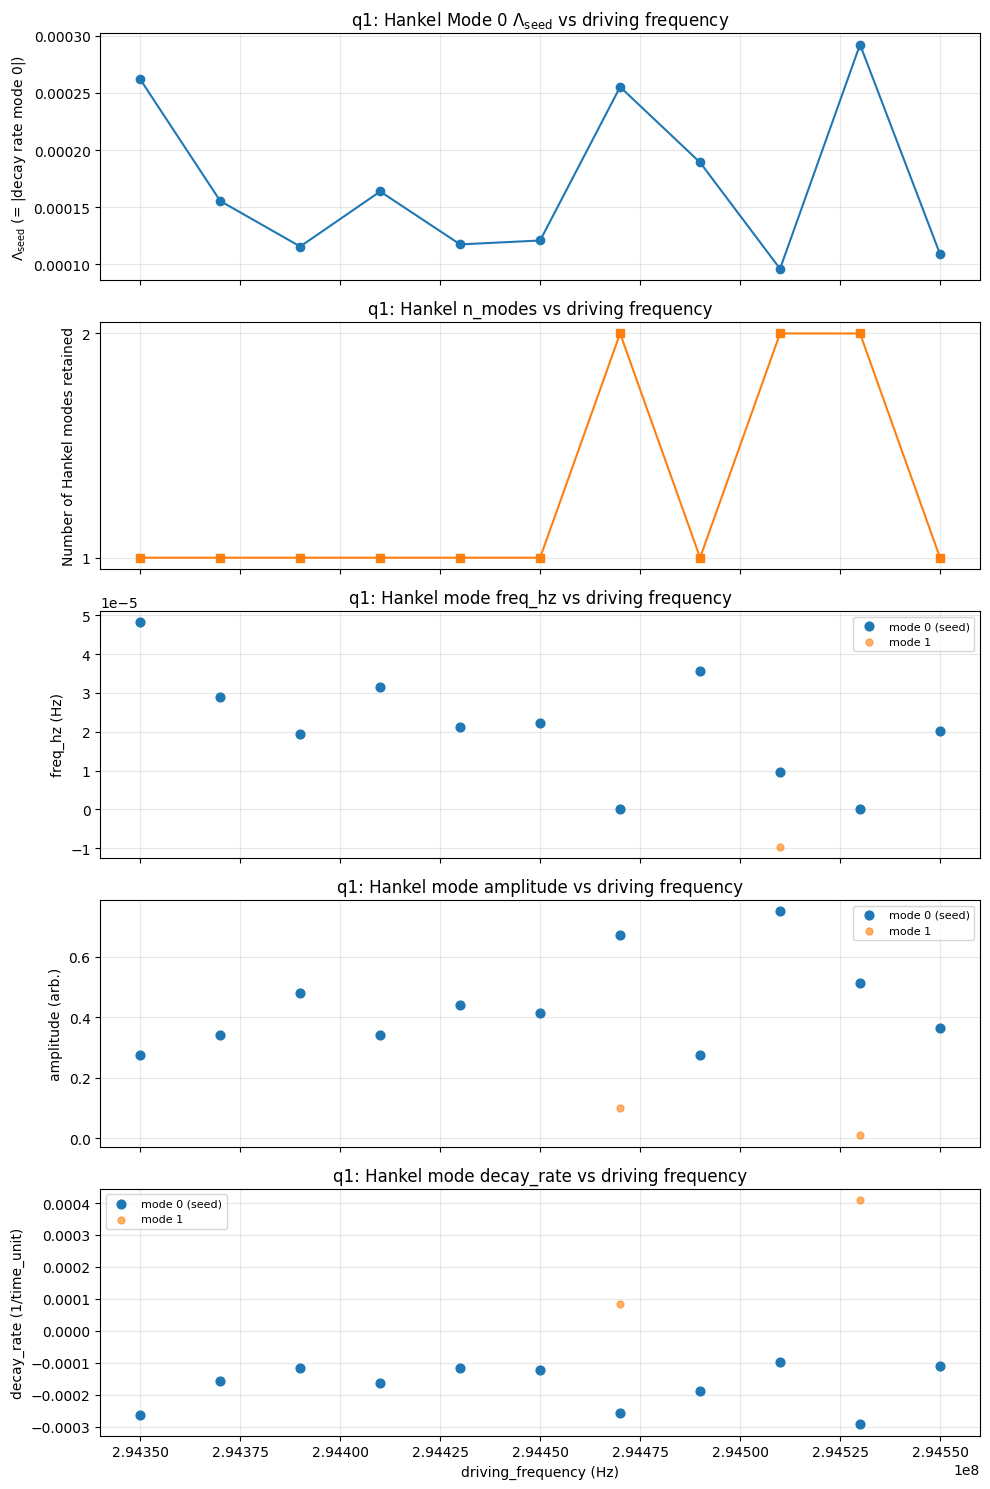

In [6]:
# --- Hankel diagnostic plots: Lambda_seed, n_modes, freq_hz, amplitude, and decay_rate vs driving_frequency ---
for i, per_freq_hankel in enumerate(hankel_diagnostics):
    try:
        qname = qubit_data[i]["qubit"].values.item() if "qubit" in qubit_data[i] else f"Dataset_{i}"
    except Exception:
        qname = f"Dataset_{i}"

    items_h = sorted(per_freq_hankel.items())
    freqs_h = np.array([f for f, _ in items_h])
    lambda_seeds = np.array(
        [d["Lambda_seed"] if d["Lambda_seed"] is not None else np.nan for _, d in items_h],
        dtype=float,
    )
    n_modes_arr = np.array([d["n_modes"] for _, d in items_h], dtype=int)

    # Collect per-mode-index data: mode_data[k] = {"drive_f": [], "freq_hz": [], "decay": [], "amplitude": []}
    mode_data = {}
    for f_drive, diag in items_h:
        modes = diag.get("modes", [])
        for k, mode in enumerate(modes):
            if k not in mode_data:
                mode_data[k] = {"drive_f": [], "freq_hz": [], "decay": [], "amplitude": []}
            mode_data[k]["drive_f"].append(f_drive)
            mode_data[k]["freq_hz"].append(mode.get("freq_hz", np.nan))
            mode_data[k]["decay"].append(mode.get("decay_rate", np.nan))
            mode_data[k]["amplitude"].append(mode.get("amplitude", np.nan))

    fig, axes = plt.subplots(5, 1, figsize=(10, 15), sharex=True)

    axes[0].plot(freqs_h, lambda_seeds, "o-", color="C0")
    axes[0].set_ylabel(r"$\Lambda_\mathrm{seed}$ (= |decay rate mode 0|)")
    axes[0].set_title(rf"{qname}: Hankel Mode 0 $\Lambda_\mathrm{{seed}}$ vs driving frequency")
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(freqs_h, n_modes_arr, "s-", color="C1")
    axes[1].set_ylabel("Number of Hankel modes retained")
    axes[1].set_title(rf"{qname}: Hankel n_modes vs driving frequency")
    axes[1].yaxis.get_major_locator().set_params(integer=True)
    axes[1].grid(True, alpha=0.3)

    for k, md in sorted(mode_data.items()):
        color = f"C{k}"
        label = f"mode {k}" + (" (seed)" if k == 0 else "")
        size = 40 if k == 0 else 25
        zorder = 3 if k == 0 else 2
        alpha = 1.0 if k == 0 else 0.6
        axes[2].scatter(md["drive_f"], md["freq_hz"], s=size, color=color, zorder=zorder, alpha=alpha, label=label)
        axes[3].scatter(md["drive_f"], md["amplitude"], s=size, color=color, zorder=zorder, alpha=alpha, label=label)
        axes[4].scatter(md["drive_f"], md["decay"], s=size, color=color, zorder=zorder, alpha=alpha, label=label)

    axes[2].set_ylabel("freq_hz (Hz)")
    axes[2].set_title(rf"{qname}: Hankel mode freq_hz vs driving frequency")
    axes[2].legend(loc="best", fontsize=8)
    axes[2].grid(True, alpha=0.3)

    axes[3].set_ylabel("amplitude (arb.)")
    axes[3].set_title(rf"{qname}: Hankel mode amplitude vs driving frequency")
    axes[3].legend(loc="best", fontsize=8)
    axes[3].grid(True, alpha=0.3)

    axes[4].set_ylabel("decay_rate (1/time_unit)")
    axes[4].set_xlabel("driving_frequency (Hz)")
    axes[4].set_title(rf"{qname}: Hankel mode decay_rate vs driving frequency")
    axes[4].legend(loc="best", fontsize=8)
    axes[4].grid(True, alpha=0.3)

    fig.tight_layout()
    plt.show()


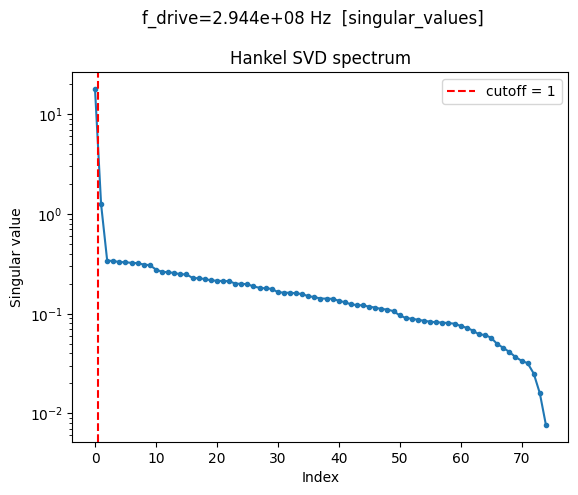

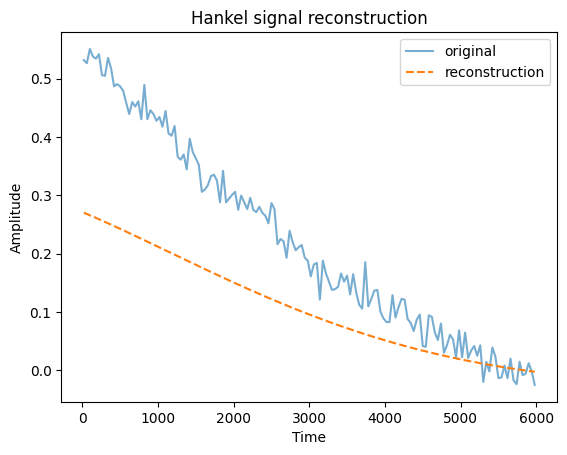

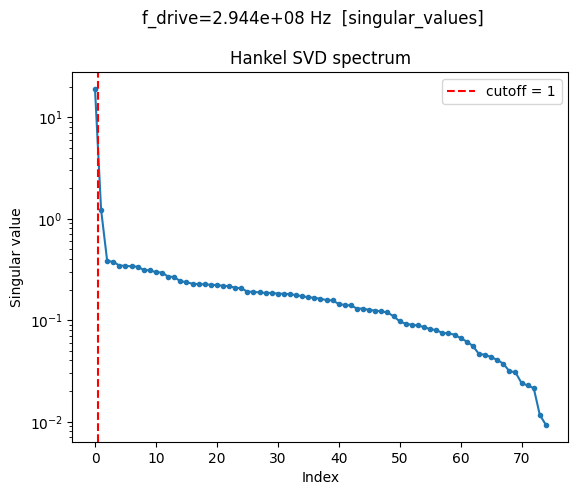

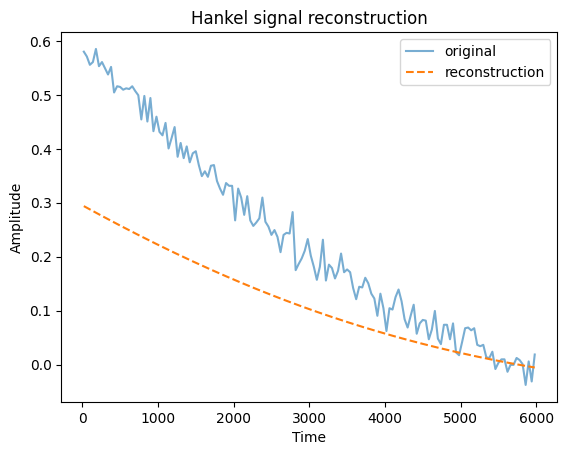

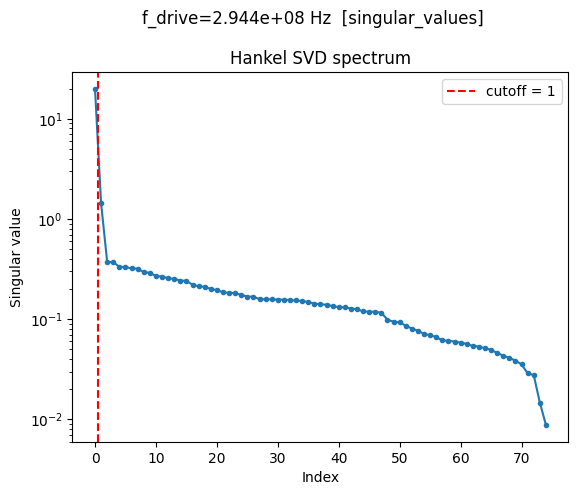

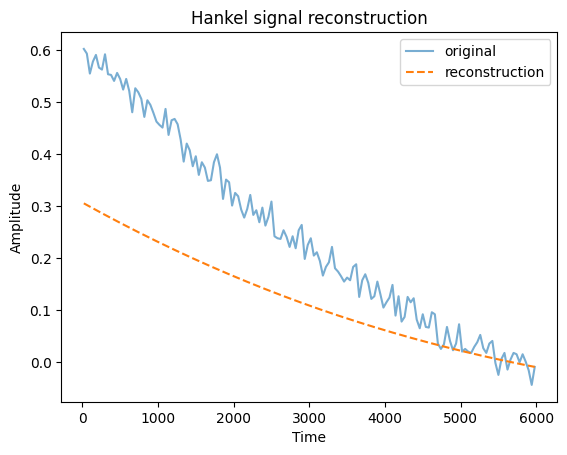

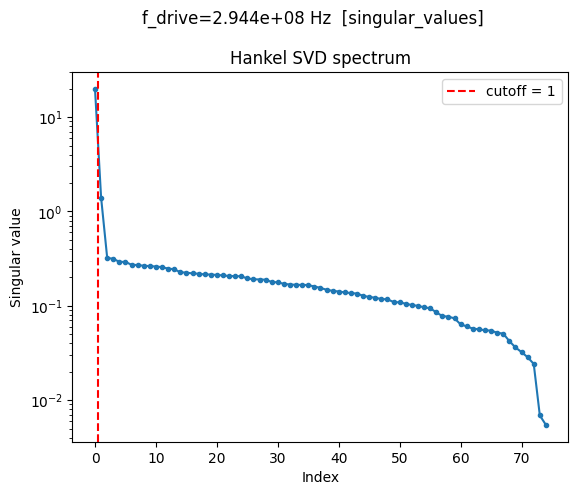

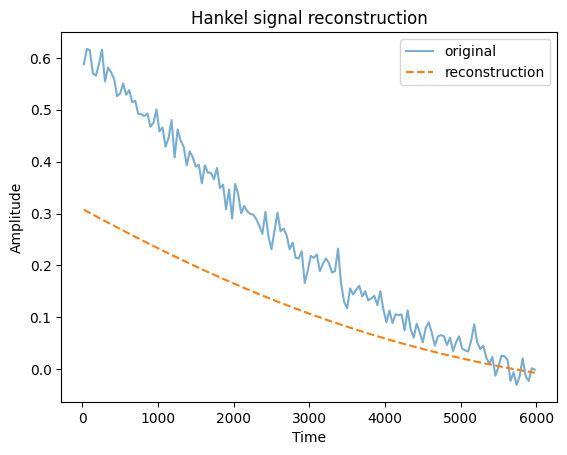

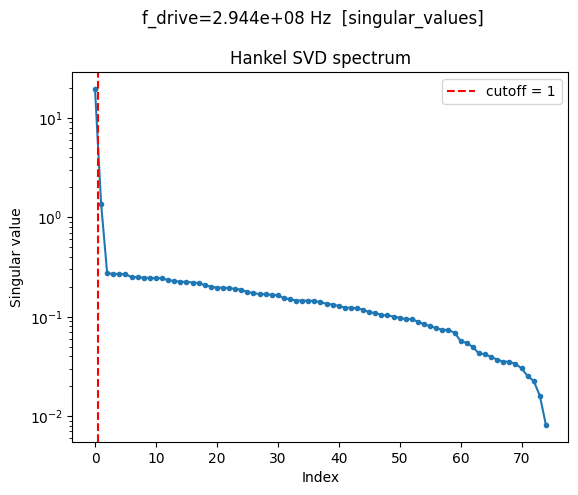

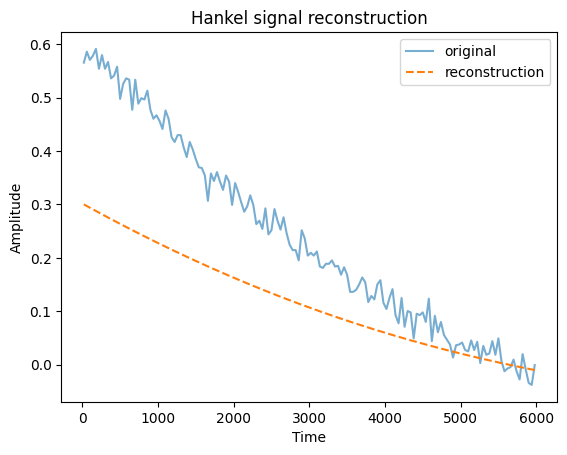

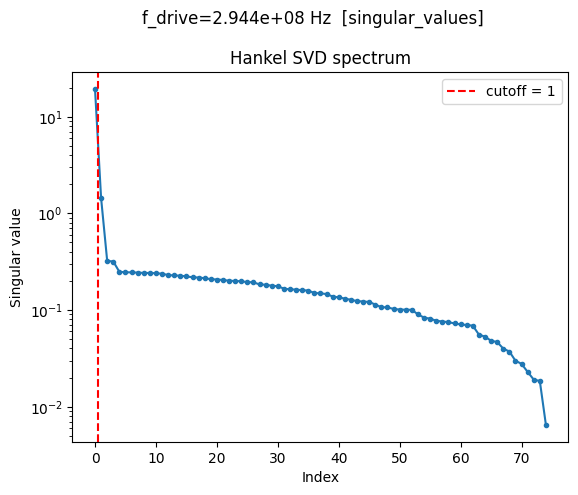

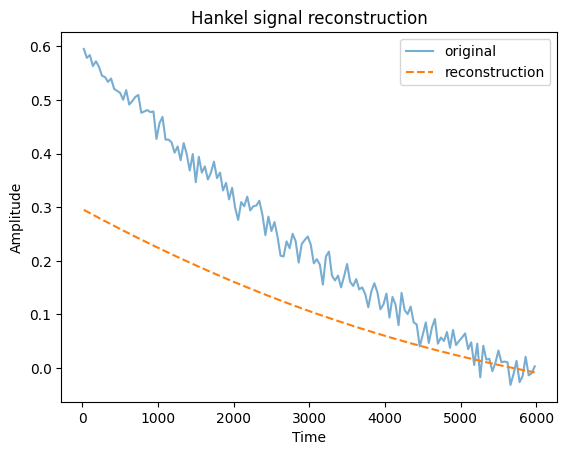

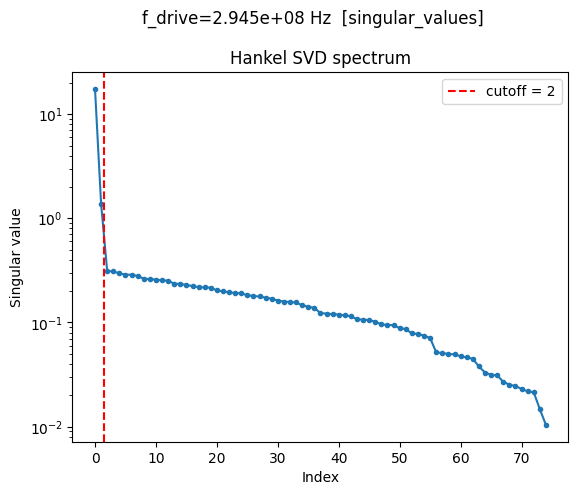

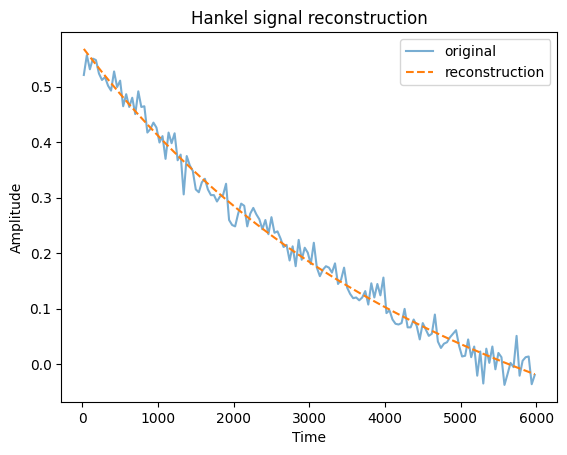

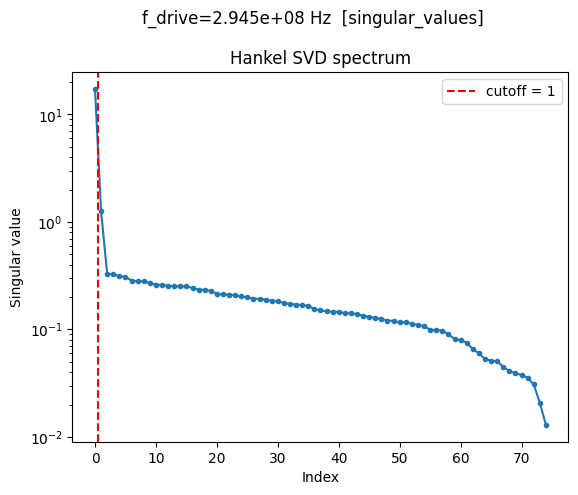

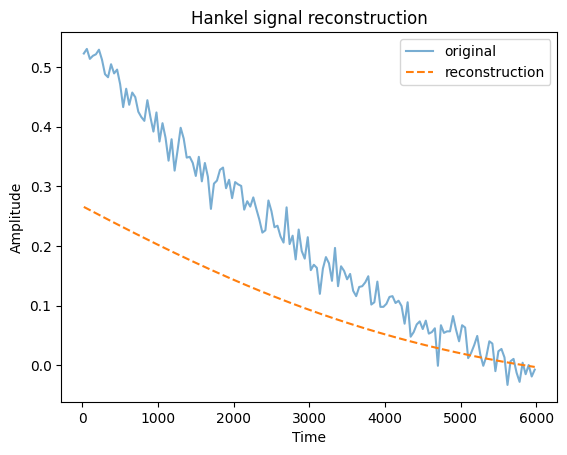

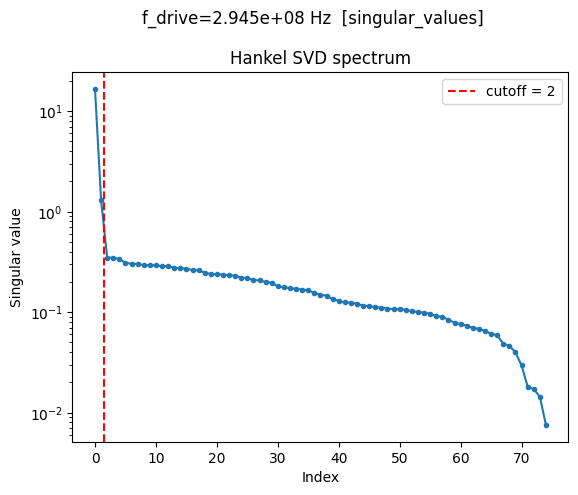

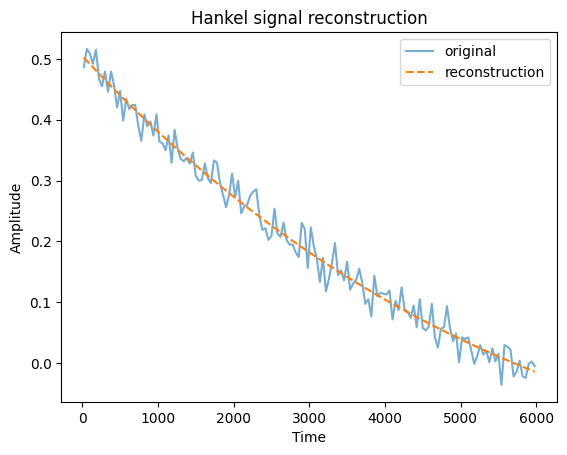

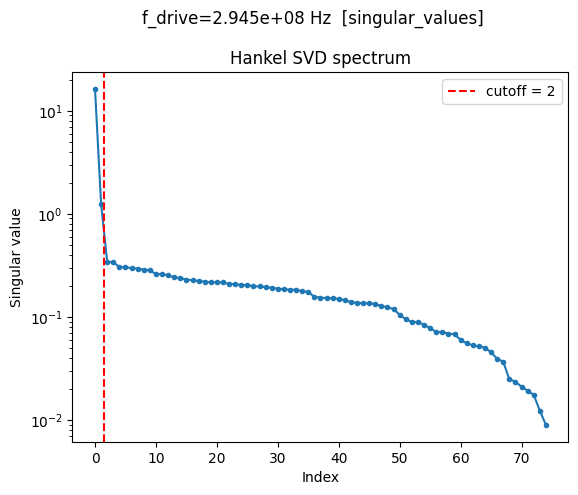

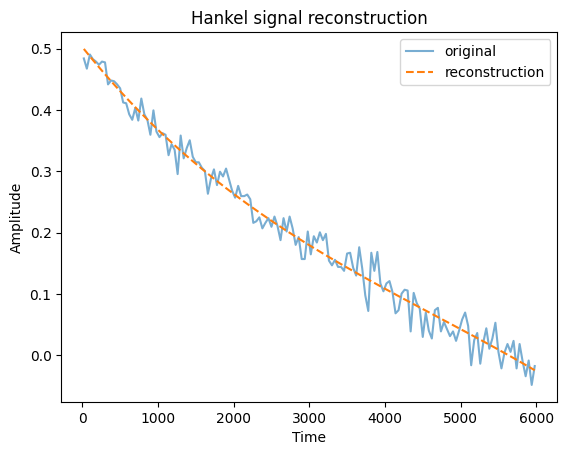

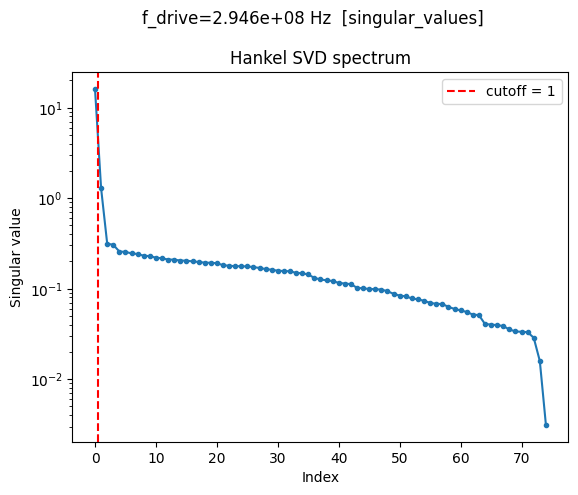

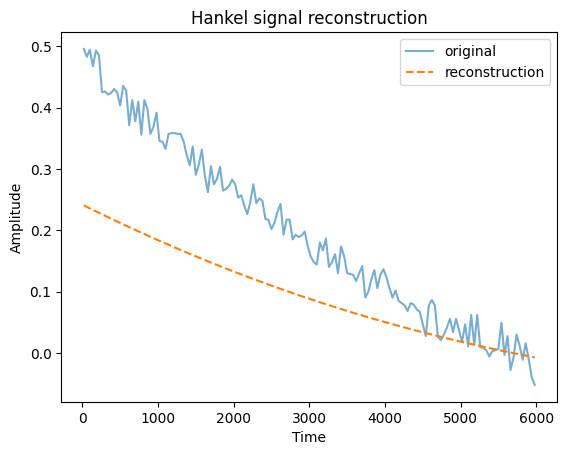

In [7]:
# --- Hankel generate_figures: SVD spectrum + signal reconstruction per driving_frequency ---
# hankel_diagnostics now contains 'singular_values' and 'reconstruction' from the pipeline,
# so we can call HankelAnalyzer.generate_figures without re-running the analysis.

from scqat.protocols.hankel_analysis import HankelAnalyzer

_hankel_analyzer = HankelAnalyzer()

qubit_idx = 0          # change to inspect a different qubit
# Set to a numeric driving_frequency value, or None to loop over all frequencies.
plot_freq = None

per_freq_hankel = hankel_diagnostics[qubit_idx]
rho_ds = rho_datasets[qubit_idx]

freqs_to_plot = (
    [plot_freq] if plot_freq is not None
    else sorted(per_freq_hankel.keys())
)

for f_val in freqs_to_plot:
    diag = per_freq_hankel.get(float(f_val))
    if diag is None or diag.get("singular_values") is None:
        print(f"f={float(f_val):.4g}: no Hankel results, skipping.")
        continue

    # Reconstruct the hankel_ds so generate_figures can access the signal
    sub = rho_ds.sel(driving_frequency=f_val)
    t_arr = sub.coords["driving_time"].values.astype(float)
    y_arr = sub["rho_11"].values.astype(float)
    tail = max(int(0.1 * len(y_arr)), 1)
    signal = y_arr - float(np.mean(y_arr[-tail:]))
    hankel_ds = xr.Dataset({"signal": ("time", signal)}, coords={"time": t_arr})

    results_dict = {
        "singular_values": diag["singular_values"],
        "n_modes": diag["n_modes"],
        "reconstruction": diag["reconstruction"],
    }

    figs = _hankel_analyzer.generate_figures(hankel_ds, results_dict)
    for fig_name, fig in figs.items():
        fig.suptitle(f"f_drive={float(f_val):.4g} Hz  [{fig_name}]", y=1.01)
        plt.show()
        plt.close(fig)


## Multi-Damped-Oscillation Fit (Hankel-Seeded)

Independent of the non-Markovian fit above, this section fits the same
tail-mean-subtracted $\rho_{11}(t)$ trace to a sum of damped oscillations
$$y(t) = \sum_i a_i e^{k_i t}\cos(2\pi f_i t + \phi_i) + c$$
with the number of components and the initial seeds taken directly from the
Hankel modes computed earlier. All parameters are free.

Results are stored in `mdo_fit_results[qubit_index][driving_frequency]`.

In [8]:
# Multi-damped-oscillation fits are produced by `analyze_file` and stored in
# `mdo_fit_results[qubit_index][driving_frequency]`. Print a quick success summary.
for i, per_freq_mdo in enumerate(mdo_fit_results):
    qname = results[i]["qubit_name"]
    n_ok = sum(1 for v in per_freq_mdo.values() if v is not None and v.get("success"))
    print(f"[{qname}] multi-damped-osc fits succeeded: {n_ok}/{len(per_freq_mdo)}")

[q1] multi-damped-osc fits succeeded: 11/11


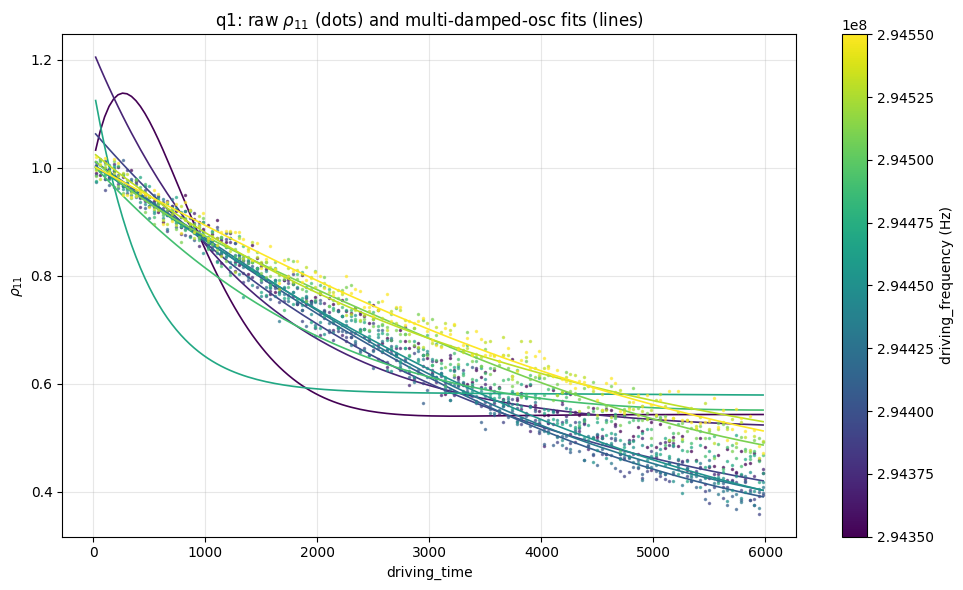

In [9]:
# --- Overlay multi-damped-oscillation fit on raw rho_11 traces, colored by driving_frequency ---
for i, (rho_ds, per_freq_mdo) in enumerate(zip(rho_datasets, mdo_fit_results)):
    try:
        qname = qubit_data[i]['qubit'].values.item() if 'qubit' in qubit_data[i] else f'Dataset_{i}'
    except Exception:
        qname = f'Dataset_{i}'

    t = rho_ds.coords['driving_time'].values.astype(float)
    freqs_sorted = np.sort(np.array(list(per_freq_mdo.keys())))
    if len(freqs_sorted) == 0:
        continue

    cmap = plt.get_cmap('viridis')
    norm = plt.Normalize(vmin=freqs_sorted.min(), vmax=freqs_sorted.max())

    fig, ax = plt.subplots(figsize=(10, 6))
    for f_val in freqs_sorted:
        color = cmap(norm(f_val))
        y_data = rho_ds['rho_11'].sel(driving_frequency=f_val).values
        ax.plot(t, y_data, '.', ms=3, color=color, alpha=0.6)

        res = per_freq_mdo.get(f_val)
        if res is not None:
            # fit_curve is on the baseline-subtracted signal; add baseline back for display.
            ax.plot(t, res['fit_curve'] + res.get('baseline', 0.0), '-', lw=1.2, color=color)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label('driving_frequency (Hz)')

    ax.set_xlabel('driving_time')
    ax.set_ylabel(r'$\rho_{11}$')
    ax.set_title(rf'{qname}: raw $\rho_{{11}}$ (dots) and multi-damped-osc fits (lines)')
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()


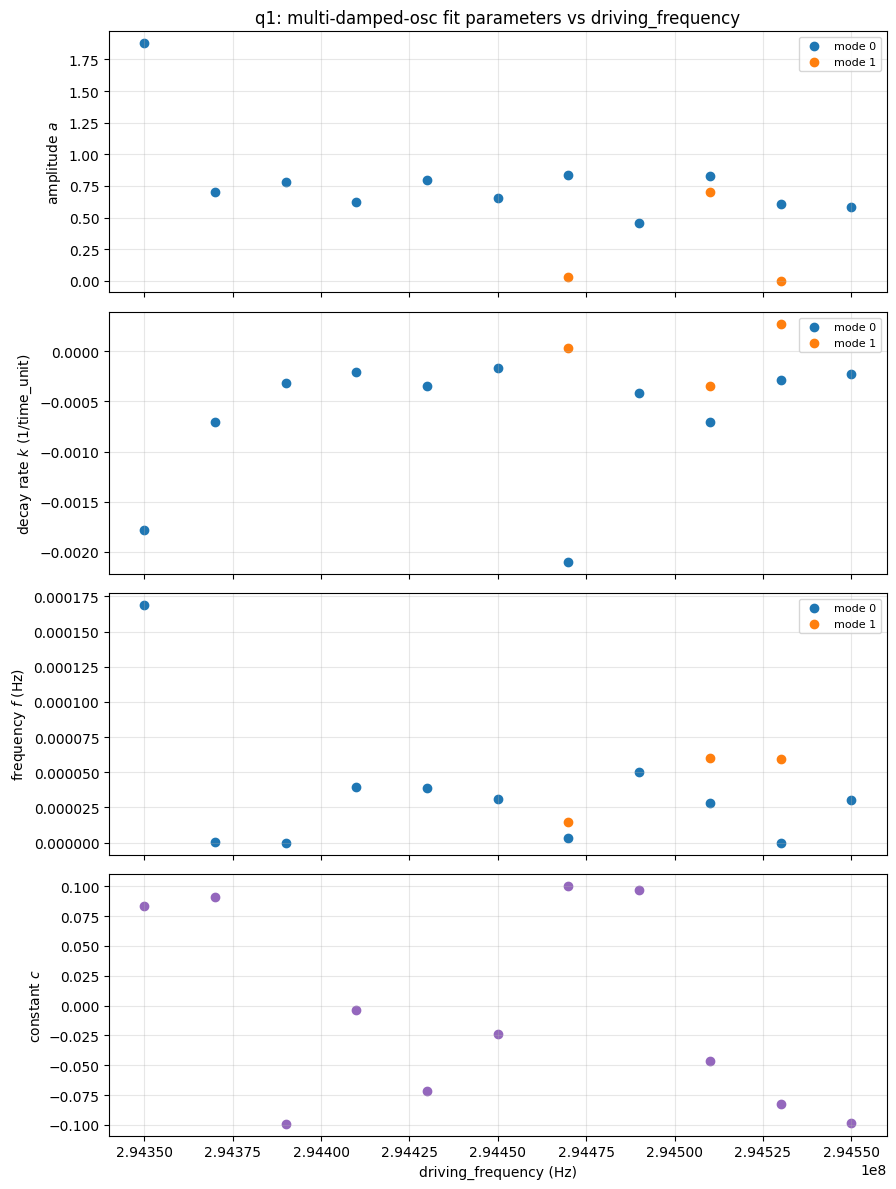

In [10]:
# --- Per-mode parameter summary from the multi-damped-osc fit vs driving_frequency ---
for i, per_freq_mdo in enumerate(mdo_fit_results):
    try:
        qname = qubit_data[i]['qubit'].values.item() if 'qubit' in qubit_data[i] else f'Dataset_{i}'
    except Exception:
        qname = f'Dataset_{i}'

    items = sorted([(f, r) for f, r in per_freq_mdo.items() if r is not None])
    if not items:
        print(f'[{qname}] no successful multi-damped-osc fits.')
        continue

    # Group by mode index (mode 0 = largest-amplitude in the Hankel seed ordering).
    mode_data = {}
    for f_drive, r in items:
        for k, m in enumerate(r['modes']):
            mode_data.setdefault(k, {'drive_f': [], 'a': [], 'k_decay': [], 'f_hz': []})
            mode_data[k]['drive_f'].append(f_drive)
            mode_data[k]['a'].append(m['a'])
            mode_data[k]['k_decay'].append(m['k'])
            mode_data[k]['f_hz'].append(m['f'])

    # Collect c (constant offset) per driving_frequency
    c_drive_f = [f_drive for f_drive, r in items]
    c_vals = [r['c'] for _, r in items]

    fig, axes = plt.subplots(4, 1, figsize=(9, 12), sharex=True)
    for k, md in sorted(mode_data.items()):
        color = f'C{k}'
        label = f'mode {k}'
        axes[0].scatter(md['drive_f'], md['a'], color=color, label=label)
        axes[1].scatter(md['drive_f'], md['k_decay'], color=color, label=label)
        axes[2].scatter(md['drive_f'], md['f_hz'], color=color, label=label)

    axes[3].scatter(c_drive_f, c_vals, color='C4')

    axes[0].set_ylabel('amplitude $a$')
    axes[0].set_title(f'{qname}: multi-damped-osc fit parameters vs driving_frequency')
    axes[0].legend(fontsize=8)
    axes[0].grid(True, alpha=0.3)

    axes[1].set_ylabel('decay rate $k$ (1/time_unit)')
    axes[1].legend(fontsize=8)
    axes[1].grid(True, alpha=0.3)

    axes[2].set_ylabel('frequency $f$ (Hz)')
    axes[2].legend(fontsize=8)
    axes[2].grid(True, alpha=0.3)

    axes[3].set_ylabel('constant $c$')
    axes[3].set_xlabel('driving_frequency (Hz)')
    axes[3].grid(True, alpha=0.3)

    fig.tight_layout()
    plt.show()


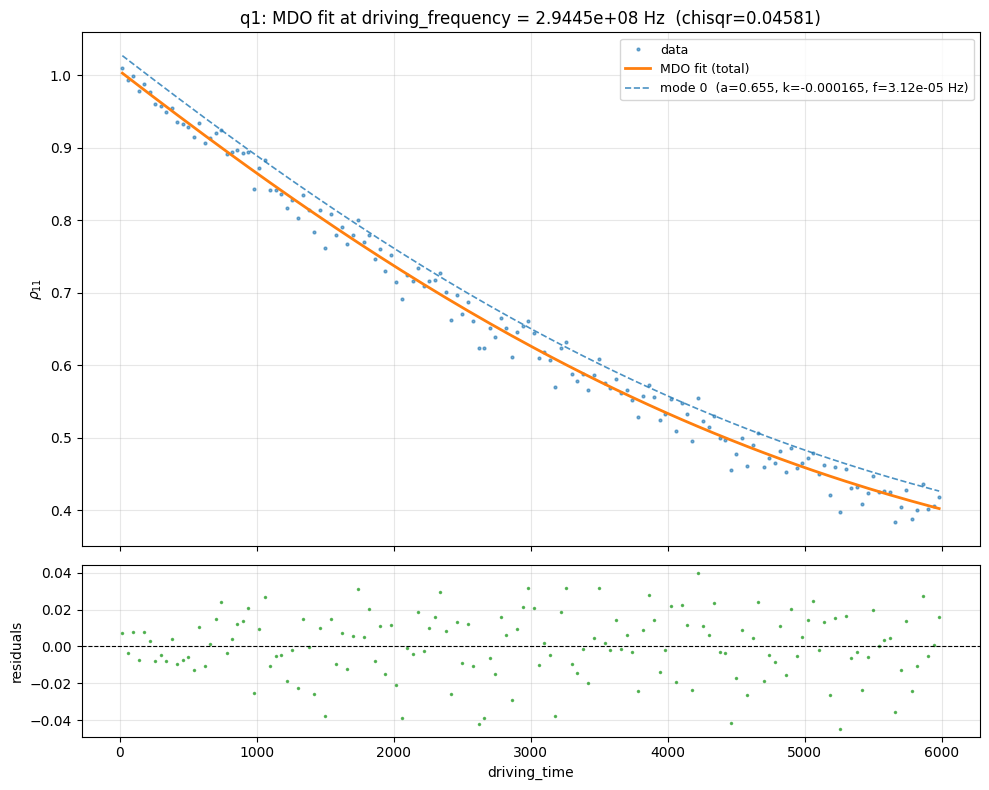

driving_frequency = 2.9445e+08 Hz
  n_modes = 1,  chisqr = 0.04581
  mode 0: a=0.6547,  k=-0.0001653 (1/time_unit),  f=3.122e-05 Hz,  phi=0.3504 rad
  c (offset) = -0.02413


In [11]:
# --- Optional: inspect a single MDO fit (data + model overlay) for one driving_frequency ---
qubit_idx = 0
target_freq_mdo = "best"  # "best" -> pick freq with minimum chisqr; or set a numeric value

rho_ds = rho_datasets[qubit_idx]
per_freq_mdo = mdo_fit_results[qubit_idx]

if target_freq_mdo == "best":
    valid = [(f, r) for f, r in per_freq_mdo.items() if r is not None and np.isfinite(r["chisqr"])]
    if not valid:
        raise RuntimeError("No successful MDO fits available.")
    f_val, _ = min(valid, key=lambda x: x[1]["chisqr"])
elif target_freq_mdo is None:
    freqs = rho_ds.coords["driving_frequency"].values
    f_val = freqs[len(freqs) // 2]
else:
    freqs = rho_ds.coords["driving_frequency"].values
    f_val = freqs[np.argmin(np.abs(freqs - target_freq_mdo))]

try:
    qname = qubit_data[qubit_idx]["qubit"].values.item() if "qubit" in qubit_data[qubit_idx] else f"Dataset_{qubit_idx}"
except Exception:
    qname = f"Dataset_{qubit_idx}"

sub = rho_ds.sel(driving_frequency=f_val)
t = sub.coords["driving_time"].values.astype(float)
y_raw = sub["rho_11"].values.astype(float)

res = per_freq_mdo[float(f_val)]
baseline = res.get("baseline", 0.0)

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True,
                         gridspec_kw={"height_ratios": [3, 1]})

# Top: data + total fit + per-mode contributions
axes[0].plot(t, y_raw, ".", ms=4, color="C0", alpha=0.6, label="data")
axes[0].plot(t, res["fit_curve"] + baseline, "-", lw=2, color="C1", label="MDO fit (total)")

for k, mode in enumerate(res["modes"]):
    y_mode = multi_damped_osc_eval(
        t,
        [{"a": mode["a"], "k": mode["k"], "f": mode["f"], "phi": mode["phi"]}],
        c=0.0,
    )
    axes[0].plot(
        t, y_mode + baseline, "--", lw=1.2, alpha=0.8,
        label=f"mode {k}  (a={mode['a']:.3g}, k={mode['k']:.3g}, f={mode['f']:.3g} Hz)",
    )

axes[0].set_ylabel(r"$\rho_{11}$")
axes[0].set_title(
    rf"{qname}: MDO fit at driving_frequency = {f_val:.6g} Hz  (chisqr={res['chisqr']:.4g})"
)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Bottom: residuals
axes[1].plot(t, res["residuals"], ".", ms=3, color="C2", alpha=0.7)
axes[1].axhline(0, color="k", lw=0.8, ls="--")
axes[1].set_xlabel("driving_time")
axes[1].set_ylabel("residuals")
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

print(f"driving_frequency = {f_val:.6g} Hz")
print(f"  n_modes = {res['n_modes']},  chisqr = {res['chisqr']:.4g}")
for k, m in enumerate(res["modes"]):
    print(f"  mode {k}: a={m['a']:.4g},  k={m['k']:.4g} (1/time_unit),  f={m['f']:.4g} Hz,  phi={m['phi']:.4g} rad")
print(f"  c (offset) = {res['c']:.4g}")


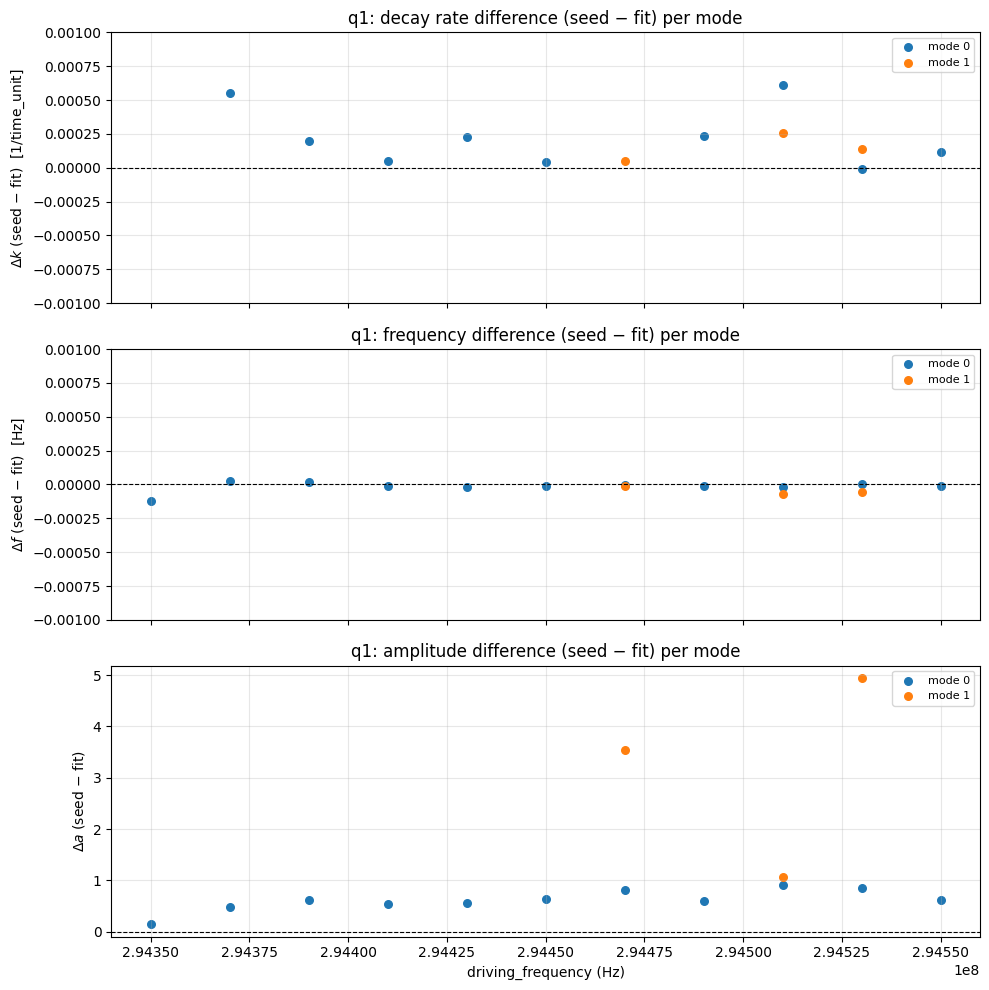

In [12]:
# --- Difference (seed - fit) for k_decay and f_hz per mode vs driving_frequency ---
for i, per_freq_mdo in enumerate(mdo_fit_results):
    try:
        qname = qubit_data[i]['qubit'].values.item() if 'qubit' in qubit_data[i] else f'Dataset_{i}'
    except Exception:
        qname = f'Dataset_{i}'

    items = sorted([(f, r) for f, r in per_freq_mdo.items() if r is not None])
    if not items:
        print(f'[{qname}] no successful multi-damped-osc fits.')
        continue

    max_modes = max(r['n_modes'] for _, r in items)

    fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

    for k in range(max_modes):
        color = f'C{k}'
        label = f'mode {k}'

        drive_f_diff, dk_diff, df_diff, da_diff = [], [], [], []

        for f_drive, r in items:
            if k >= r['n_modes']:
                continue
            diag = hankel_diagnostics[i].get(float(f_drive), {})
            seed_modes = diag.get('modes', [])
            if k >= len(seed_modes):
                continue

            k_fit_val = r['modes'][k]['k']
            f_fit_val = r['modes'][k]['f']
            a_fit_val = r['modes'][k]['a']
            k_seed_val = seed_modes[k].get('decay_rate', np.nan)
            f_seed_val = seed_modes[k].get('freq_hz', np.nan)
            a_seed_val = seed_modes[k].get('amplitude', np.nan)

            drive_f_diff.append(f_drive)
            dk_diff.append(k_seed_val - k_fit_val)
            df_diff.append(f_seed_val - f_fit_val)
            da_diff.append(a_seed_val / a_fit_val)

        if drive_f_diff:
            axes[0].scatter(drive_f_diff, dk_diff, color=color, marker='o', s=30, label=label)
            axes[1].scatter(drive_f_diff, df_diff, color=color, marker='o', s=30, label=label)
            axes[2].scatter(drive_f_diff, da_diff, color=color, marker='o', s=30, label=label)

    axes[0].axhline(0, color='k', lw=0.8, ls='--')
    axes[0].set_ylabel(r'$\Delta k$ (seed $-$ fit)  [1/time_unit]')
    axes[0].set_title(f'{qname}: decay rate difference (seed − fit) per mode')
    axes[0].set_ylim(-0.001, 0.001)
    axes[0].legend(fontsize=8)
    axes[0].grid(True, alpha=0.3)

    axes[1].axhline(0, color='k', lw=0.8, ls='--')
    axes[1].set_ylabel(r'$\Delta f$ (seed $-$ fit)  [Hz]')
    axes[1].set_title(f'{qname}: frequency difference (seed − fit) per mode')
    axes[1].set_ylim(-0.001, 0.001)
    axes[1].legend(fontsize=8)
    axes[1].grid(True, alpha=0.3)

    axes[2].axhline(0, color='k', lw=0.8, ls='--')
    axes[2].set_ylabel(r'$\Delta a$ (seed $-$ fit)')
    axes[2].set_xlabel('driving_frequency (Hz)')
    axes[2].set_title(f'{qname}: amplitude difference (seed − fit) per mode')
    axes[2].legend(fontsize=8)
    axes[2].grid(True, alpha=0.3)

    fig.tight_layout()
    plt.show()


# DecoherenceAnalyzer (Hankel-Seeded)

$$a = \Lambda - i\Delta$$

$$d = \sqrt{a^2 - 2\Gamma\Lambda} = \sqrt{a^2 - 4\lambda^2}$$

$$G(t) = e^{-at/2}\left[\cosh\!\left(\frac{dt}{2}\right) + \frac{a}{d}\sinh\!\left(\frac{dt}{2}\right)\right]$$

$$\rho_{11}(t) = \left|G(t)\right|^2 \rho_{11}(0)$$

## Workflow per driving_frequency:
   1. Read Lambda_seed from hankel_diagnostics (Mode 0 |decay_rate|).
   2. gamma_seed = 2 * Lambda_seed; clip to fitter bounds if needed.
   3. Run FitQubitDecoherence with the seeded gamma; reuse guess() for lambda_ and rho_0.

In [13]:
# Decoherence fits and initial guesses are produced by `analyze_file` and exposed
# above as `decoh_fit_results` and `decoh_initial_guesses`.
# Keep an analyzer instance around for the single-fit inspection cell below.
decoherence_analyzer = QubitDecoherenceAnalyzer()

for i, per_freq in enumerate(decoh_fit_results):
    qname = results[i]["qubit_name"]
    n_ok = sum(1 for v in per_freq.values() if v is not None)
    print(f"[{qname}] decoherence fits succeeded: {n_ok}/{len(per_freq)}")

[q1] decoherence fits succeeded: 11/11


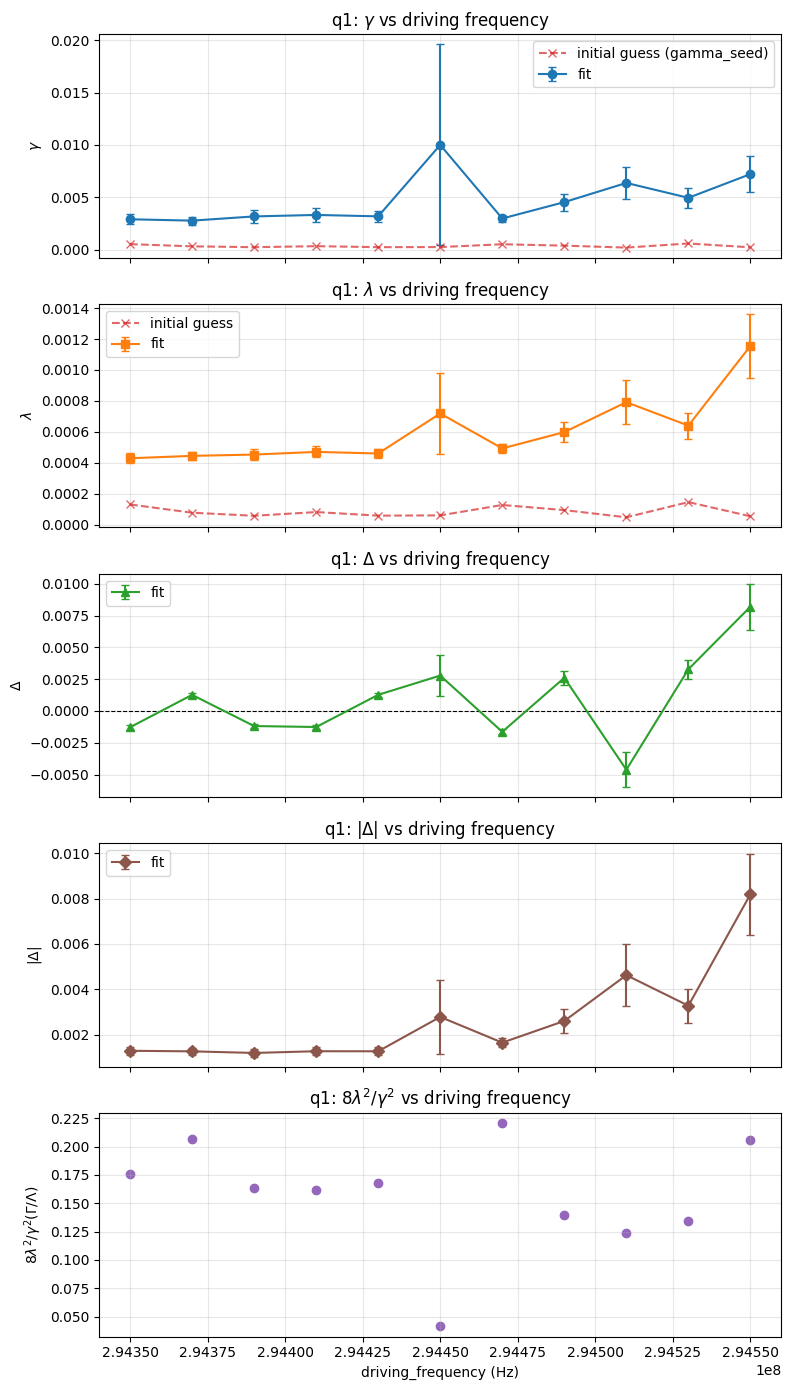

In [14]:
# --- Summary plots: gamma, lambda, Delta, |Delta|, and gamma/lambda vs driving_frequency, per qubit ---
for i, per_freq in enumerate(decoh_fit_results):
    try:
        qname = qubit_data[i]["qubit"].values.item() if "qubit" in qubit_data[i] else f"Dataset_{i}"
    except Exception:
        qname = f"Dataset_{i}"

    items = [(f, r) for f, r in per_freq.items() if r is not None]
    if not items:
        print(f"[{qname}] no successful fits to plot.")
        continue

    items.sort(key=lambda x: x[0])
    freqs = np.array([f for f, _ in items])
    gamma = np.array([r["gamma"] for _, r in items], dtype=float)
    gamma_err = np.array([r["gamma_err"] for _, r in items], dtype=float)
    lam = np.array([r["lambda_"] for _, r in items], dtype=float)
    lam_err = np.array([r["lambda_err"] for _, r in items], dtype=float)
    delta = np.array([r["Delta"] for _, r in items], dtype=float)
    delta_err = np.array([r["Delta_err"] for _, r in items], dtype=float)
    abs_delta = np.abs(delta)

    # Read initial guesses stored in the decoherence-fit cell (decoh_initial_guesses)
    guess_gamma = np.array([decoh_initial_guesses[i][f]["gamma"] for f, _ in items], dtype=float)
    guess_lam = np.array([decoh_initial_guesses[i][f]["lambda_"] for f, _ in items], dtype=float)

    # gamma/lambda with simple uncertainty propagation; guard against divide-by-zero
    with np.errstate(divide="ignore", invalid="ignore"):
        ratio = 8 * lam**2 / gamma**2   # = 4*gamma^2 / lambda, which is the EP condition

    fig, axes = plt.subplots(5, 1, figsize=(8, 14), sharex=True)
    axes[0].errorbar(freqs, gamma, yerr=gamma_err, fmt="o-", capsize=3, label="fit")
    axes[0].plot(freqs, guess_gamma, "x--", color="C3", alpha=0.7, label="initial guess (gamma_seed)")
    axes[0].set_ylabel(r"$\gamma$")
    axes[0].set_title(rf"{qname}: $\gamma$ vs driving frequency")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].errorbar(freqs, lam, yerr=lam_err, fmt="s-", color="C1", capsize=3, label="fit")
    axes[1].plot(freqs, guess_lam, "x--", color="C3", alpha=0.7, label="initial guess")
    axes[1].set_ylabel(r"$\lambda$")
    axes[1].set_title(rf"{qname}: $\lambda$ vs driving frequency")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    axes[2].errorbar(freqs, delta, yerr=delta_err, fmt="^-", color="C2", capsize=3, label="fit")
    axes[2].axhline(0, color="k", lw=0.8, ls="--")
    axes[2].set_ylabel(r"$\Delta$")
    axes[2].set_title(rf"{qname}: $\Delta$ vs driving frequency")
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    axes[3].errorbar(freqs, abs_delta, yerr=delta_err, fmt="D-", color="C5", capsize=3, label="fit")
    axes[3].set_ylabel(r"$|\Delta|$")
    axes[3].set_title(rf"{qname}: $|\Delta|$ vs driving frequency")
    axes[3].legend()
    axes[3].grid(True, alpha=0.3)

    axes[4].scatter(freqs, ratio, color="C4")
    axes[4].set_xlabel("driving_frequency (Hz)")
    axes[4].set_ylabel(r"$8\lambda^2/\gamma^2 (\Gamma/\Lambda)$")
    axes[4].set_title(rf"{qname}: $8\lambda^2/\gamma^2$ vs driving frequency")
    axes[4].grid(True, alpha=0.3)

    fig.tight_layout()
    plt.show()


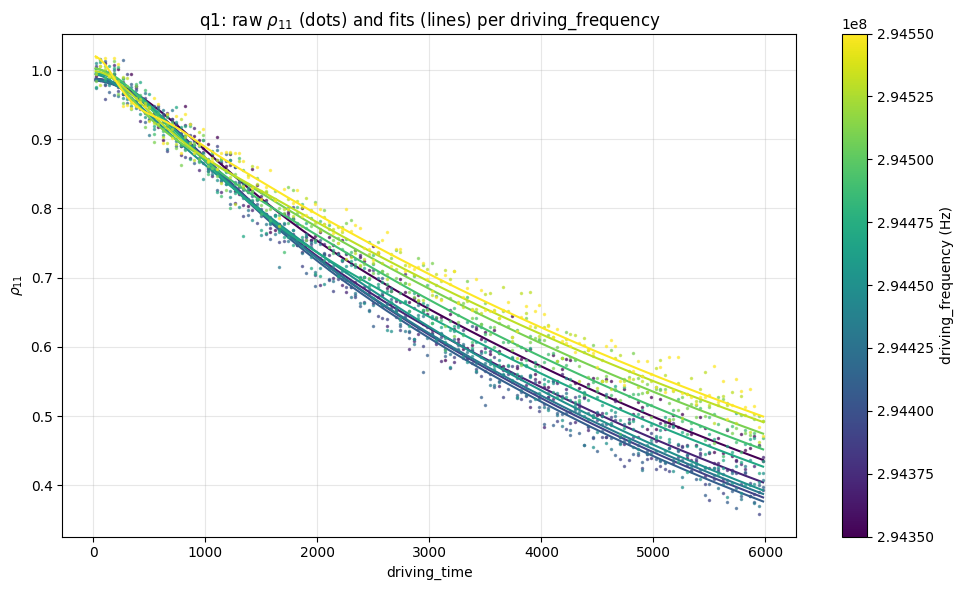

In [15]:
# --- Raw rho_11 traces and decoherence fit curves vs driving_time, colored by driving_frequency ---
for i, (rho_ds, per_freq) in enumerate(zip(rho_datasets, decoh_fit_results)):
    try:
        qname = qubit_data[i]["qubit"].values.item() if "qubit" in qubit_data[i] else f"Dataset_{i}"
    except Exception:
        qname = f"Dataset_{i}"

    t = rho_ds.coords["driving_time"].values.astype(float)
    freqs_sorted = np.sort(np.array(list(per_freq.keys())))
    if len(freqs_sorted) == 0:
        continue

    cmap = plt.get_cmap("viridis")
    norm = plt.Normalize(vmin=freqs_sorted.min(), vmax=freqs_sorted.max())

    fig, ax = plt.subplots(figsize=(10, 6))
    for f_val in freqs_sorted:
        color = cmap(norm(f_val))
        y_data = rho_ds["rho_11"].sel(driving_frequency=f_val).values
        ax.plot(t, y_data, ".", ms=3, color=color, alpha=0.6)

        res = per_freq.get(f_val)
        if res is not None:
            y_fit = rho11_model(t, res["gamma"], res["lambda_"], res["Delta"], res["rho_0"])
            ax.plot(t, y_fit, "-", lw=1.5, color=color)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label("driving_frequency (Hz)")

    ax.set_xlabel("driving_time")
    ax.set_ylabel(r"$\rho_{11}$")
    ax.set_title(rf"{qname}: raw $\rho_{{11}}$ (dots) and fits (lines) per driving_frequency")
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()


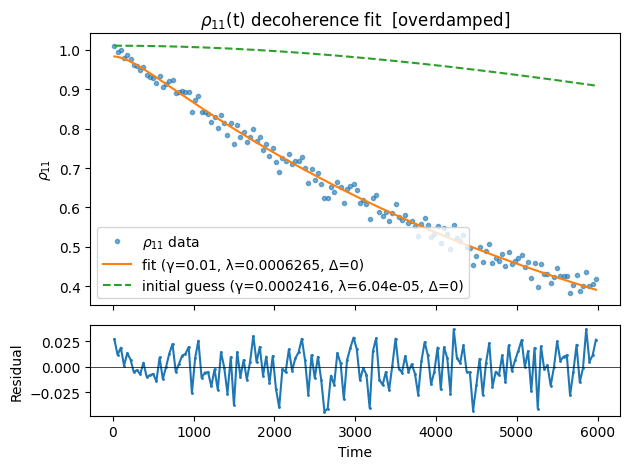

driving_frequency = 2.9445e+08 Hz
  initial guess: gamma=0.000241611, lambda=6.04028e-05, Delta=0, rho_0=1.01026
  gamma   = 0.01 ± 0.00014
  lambda  = 0.000626533 ± 9.4e-05
  Delta   = 0 ± 0
  regime  = overdamped


In [16]:
# --- Optional: inspect a single fit (data + model overlay) for one driving_frequency ---
qubit_idx = 0
target_freq = "best"  # "best" -> pick freq with minimum residual; or set a numeric value

rho_ds = rho_datasets[qubit_idx]
freqs = rho_ds.coords["driving_frequency"].values
per_freq = decoh_fit_results[qubit_idx]

if target_freq == "best":
    valid = [(f, r, r["chisqr"]) for f, r in per_freq.items() if r is not None]
    valid = [v for v in valid if np.isfinite(v[2])]
    if not valid:
        raise RuntimeError("No successful fits available to pick a 'best' frequency.")
    f_val, _, _ = min(valid, key=lambda x: x[2])
elif target_freq is None:
    f_val = freqs[len(freqs) // 2]
else:
    f_val = freqs[np.argmin(np.abs(freqs - target_freq))]

sub = rho_ds.sel(driving_frequency=f_val).rename({"driving_time": "time"})
fit_ds = sub[["rho_11"]]
results, figs = decoherence_analyzer.analyze(fit_ds, fix_delta=True)
# results, figs = decoherence_analyzer.analyze(fit_ds)

# --- Overlay the decoherence initial guess on the rho_11 figure ---
t_init = sub.coords["time"].values.astype(float)
guess = decoh_initial_guesses[qubit_idx][float(f_val)]
g0 = guess["gamma"]
l0 = guess["lambda_"]
d0 = guess.get("Delta", 0.0)
r0 = guess["rho_0"]
y_guess = rho11_model(t_init, g0, l0, d0, r0)

if "rho_11" in figs:
    ax_top = figs["rho_11"].axes[0]
    ax_top.plot(t_init, y_guess, "--", color="C2", lw=1.5,
                label=f"initial guess (\u03b3={g0:.4g}, \u03bb={l0:.4g}, \u0394={d0:.4g})")
    ax_top.legend()

for fig in figs.values():
    display(fig)
    plt.close(fig)

res = results["rho_11"]
print(f"driving_frequency = {f_val:.6g} Hz")
print(f"  initial guess: gamma={g0:.6g}, lambda={l0:.6g}, Delta={d0:.6g}, rho_0={r0:.6g}")
print(f"  gamma   = {res['gamma']:.6g} \u00b1 {res['gamma_err']:.2g}")
print(f"  lambda  = {res['lambda_']:.6g} \u00b1 {res['lambda_err']:.2g}")
print(f"  Delta   = {res['Delta']:.6g} \u00b1 {res['Delta_err']:.2g}")
print(f"  regime  = {res['regime']}")
